In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

## Loading data and helper functions

In [5]:
mg_ad_path = '/data/scRNA/RNA/scRNA/Hammond/preprocessing/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)
mg_ad

AnnData object with n_obs × n_vars = 27177 × 10570
    obs: 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [9]:
sc.pp.normalize_total(mg_ad, target_sum=1e4)
sc.pp.log1p(mg_ad)
sc.pp.scale(mg_ad, max_value=10)
sc.tl.pca(mg_ad)
sc.pp.neighbors(mg_ad)
sc.tl.umap(mg_ad)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
# Define the condition based on batch values
conditions = pd.cut(mg_ad.obs['batch'].astype(int), bins=[-1, 10, 13, 16], labels=['control', 'saline', 'LC'])

# Add the condition column to the .obs attribute of mg_ad
mg_ad.obs['condition'] = conditions

# Verify the new column
mg_ad.obs[['batch', 'condition']].head()

,batch,condition
TTAGGACAGAGGGCTT-1-0,0,control
GGCGACTTCCAAATGC-1-0,0,control
TCATTACTCGTGGACC-1-0,0,control
GCAAACTTCGGCGGTT-1-0,0,control
GGAATAATCACAGGCC-1-0,0,control


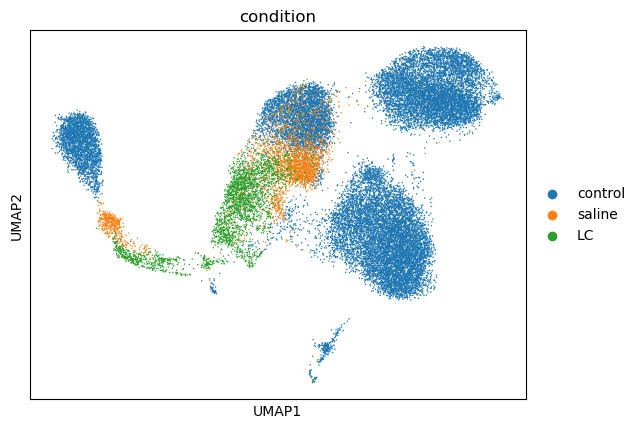

In [21]:
sc.pl.umap(mg_ad, color=['condition'])

## ME: Control modules

In [26]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_normal_NoRP_modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())
modules_df.head()

All module colors (names):  ['brown' 'blue' 'grey' 'yellow' 'turquoise']


,gene_name,module,color,kME_NORM-NoRP-M1,kME_NORM-NoRP-M2,kME_grey,kME_NORM-NoRP-M3,kME_NORM-NoRP-M4
Cd74,Cd74,NORM-NoRP-M1,brown,0.150583,0.419821,0.018544,0.175201,-0.040476
Apoe,Apoe,NORM-NoRP-M1,brown,0.152592,0.300385,0.036027,0.236322,-0.015315
H2.Ab1,H2.Ab1,NORM-NoRP-M2,blue,0.103400,0.393140,0.000632,0.121813,-0.045858
H2.Aa,H2.Aa,NORM-NoRP-M1,brown,0.124929,0.394893,-0.008771,0.112483,-0.048529
H2.Eb1,H2.Eb1,NORM-NoRP-M1,brown,0.120687,0.390966,-0.000478,0.119566,-0.055707


Number of genes in the module:  174


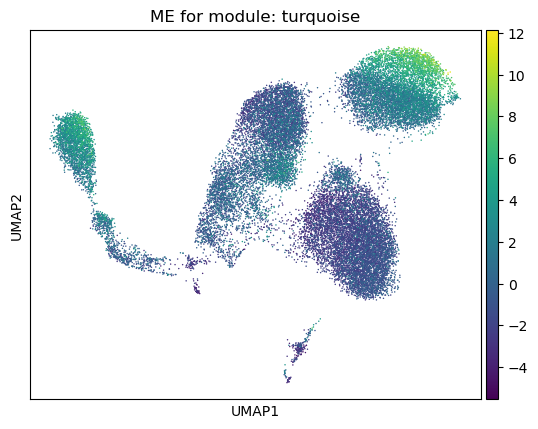

In [29]:
select_module = "turquoise"
select_genes = modules_df[modules_df["color"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = mg_ad.var_names.intersection(select_genes)
adata_subset = mg_ad[:,common_genes].copy()
# sc.pp.normalize_total(adata_subset, target_sum=1e4)
# sc.pp.log1p(adata_subset)
# sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
adata_subset.obs["ME"] = adata_subset.obsm['X_pca'][:, 0]
sc.pl.umap(adata_subset, color="ME", title=f"ME for module: {select_module}")

## ME: saline modules

In [35]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_saline_NoRP_modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())
modules_df.head()

All module colors (names):  ['blue' 'grey' 'brown' 'turquoise']


,gene_name,module,color,kME_SALINE-NoRP-M1,kME_grey,kME_SALINE-NoRP-M2,kME_SALINE-NoRP-M3
Apoe,Apoe,SALINE-NoRP-M1,blue,0.328732,0.441214,0.320913,0.270716
Ccl4,Ccl4,grey,grey,0.162866,0.414139,0.149515,0.129828
Ccl12,Ccl12,SALINE-NoRP-M1,blue,0.543086,0.105978,0.105050,0.050860
Ccl3,Ccl3,SALINE-NoRP-M1,blue,0.093986,0.320780,0.147746,0.129622
Lpl,Lpl,SALINE-NoRP-M1,blue,0.235353,0.472862,0.204790,0.199218


Number of genes in the module:  224


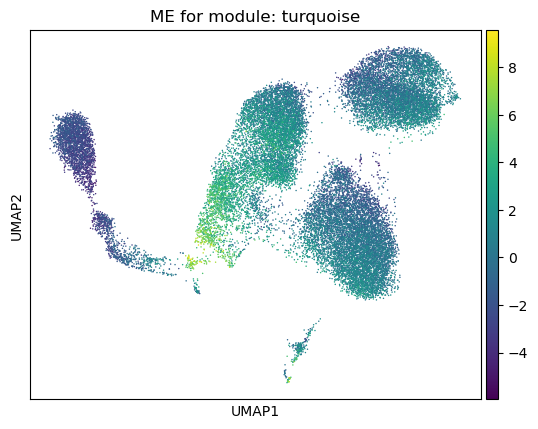

In [33]:
select_module = "turquoise"
select_genes = modules_df[modules_df["color"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = mg_ad.var_names.intersection(select_genes)
adata_subset = mg_ad[:,common_genes].copy()
# sc.pp.normalize_total(adata_subset, target_sum=1e4)
# sc.pp.log1p(adata_subset)
# sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
adata_subset.obs["ME"] = adata_subset.obsm['X_pca'][:, 0]
sc.pl.umap(adata_subset, color="ME", title=f"ME for module: {select_module}")

## ME: LC modules

In [36]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_injury_NoRP_modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())
modules_df.head()

All module colors (names):  ['turquoise' 'brown' 'grey' 'blue']


,gene_name,module,color,kME_INJURY-NORP-M1,kME_INJURY-NORP-M2,kME_grey,kME_INJURY-NORP-M3
Ccl4,Ccl4,INJURY-NORP-M1,turquoise,0.449157,0.202290,0.093461,-0.192942
Cxcl10,Cxcl10,INJURY-NORP-M1,turquoise,0.448920,0.072827,0.053286,-0.153673
Ccl5,Ccl5,INJURY-NORP-M1,turquoise,0.306227,0.095109,0.015581,-0.194044
Ccl3,Ccl3,INJURY-NORP-M1,turquoise,0.413146,0.229298,0.095060,-0.208930
Ccl12,Ccl12,INJURY-NORP-M1,turquoise,0.496430,0.123100,0.075157,-0.224386


Number of genes in the module:  127


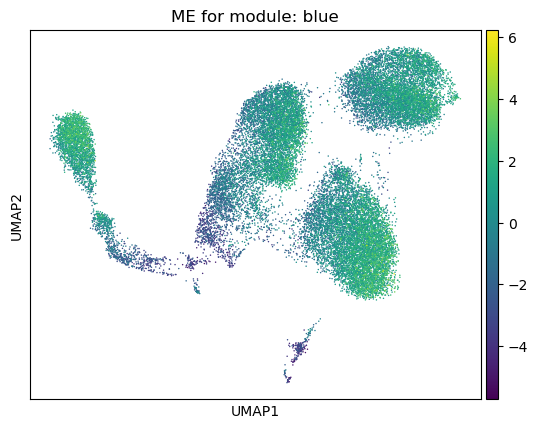

In [39]:
select_module = "blue"
select_genes = modules_df[modules_df["color"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = mg_ad.var_names.intersection(select_genes)
adata_subset = mg_ad[:,common_genes].copy()
# sc.pp.normalize_total(adata_subset, target_sum=1e4)
# sc.pp.log1p(adata_subset)
# sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
adata_subset.obs["ME"] = adata_subset.obsm['X_pca'][:, 0]
sc.pl.umap(adata_subset, color="ME", title=f"ME for module: {select_module}")

In [23]:
from matplotlib.lines import Line2D

def plot_umap(xx, yy, cc=None, val=None, label_column=None, fig_width=6, fig_height=6, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.5, marker='.')
    
    # Set axis properties
    ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

In [22]:
def plot_ME(adata_subset):
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]

    # Plot the first principal component
    plt.figure(figsize=(6, 6))
    plt.scatter(adata_subset.obs["x"], adata_subset.obs["y"], c=pc1_values, cmap='viridis', s=0.5)
    plt.colorbar(label='PC1')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Module Eigengene on UMAP for module: {select_module}')
    plt.axis('equal')
    plt.show()

In [21]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Microglia-raw-meta-wgcna-modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())

All module colors (names):  ['turquoise' 'grey' 'brown' 'blue' 'yellow']


## ME plot: only microglial cells

In [ ]:
mg_ad_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/WMB-10Xv3-Microglia-raw-wmeta.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)

(<Figure size 600x600 with 1 Axes>, <Axes: >)

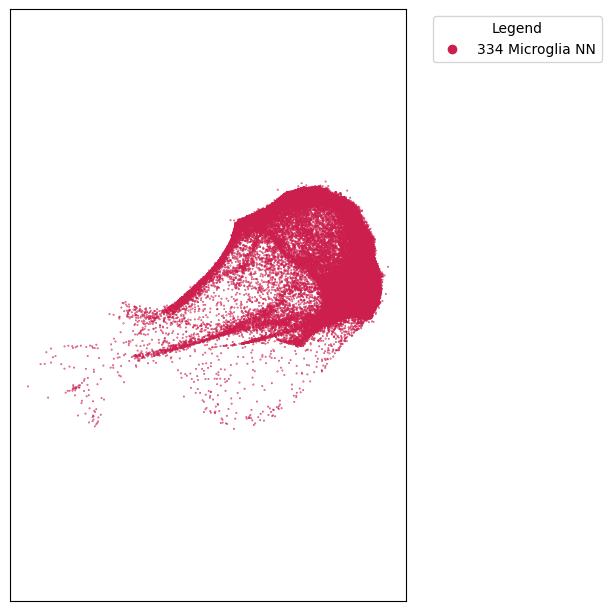

In [6]:
plot_umap(mg_ad.obs['x'], mg_ad.obs['y'], cc=mg_ad.obs['subclass_color'], label_column=mg_ad.obs['subclass'])

(<Figure size 600x600 with 1 Axes>, <Axes: >)

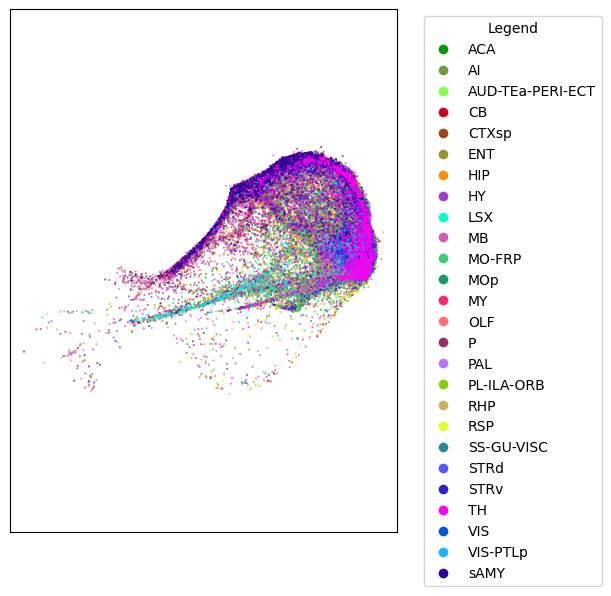

In [7]:
plot_umap(mg_ad.obs['x'], mg_ad.obs['y'], cc=mg_ad.obs['region_of_interest_color'], label_column=mg_ad.obs['region_of_interest_acronym'])

Number of genes in the module:  16


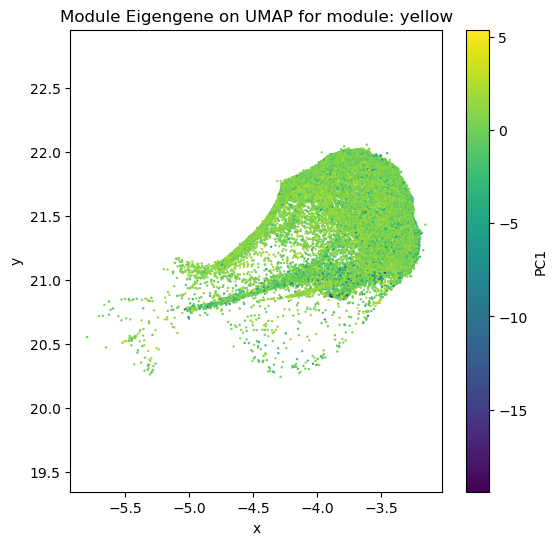

In [24]:
select_module = "yellow"
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = mg_ad.var_names.intersection(select_genes)
adata_subset = mg_ad[:,common_genes].copy()
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
plot_ME(adata_subset)

## Microglia MEs in all cells of one region

In [18]:
expr_path = "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/processed/WMB-10Xv3-Isocortex-1-raw-wmeta.h5ad"
iso_ad = sc.read_h5ad(expr_path)
iso_ad

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

(<Figure size 600x600 with 1 Axes>, <Axes: >)

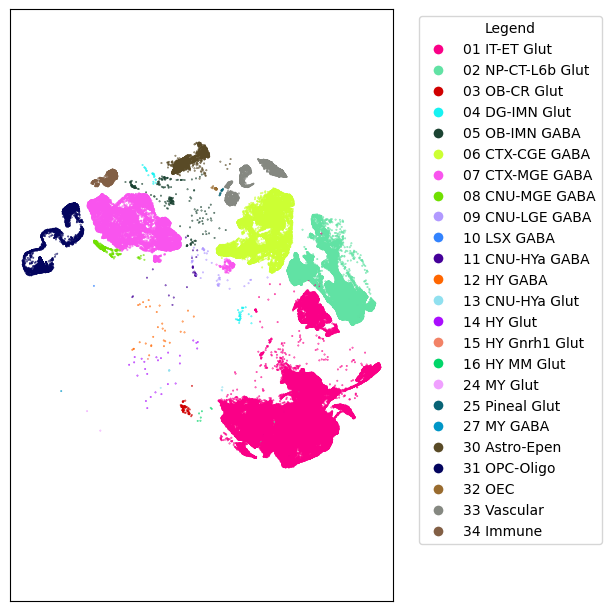

In [27]:
plot_umap(iso_ad.obs['x'], iso_ad.obs['y'], cc=iso_ad.obs['class_color'], label_column=iso_ad.obs['class'])

Number of genes in the module:  16


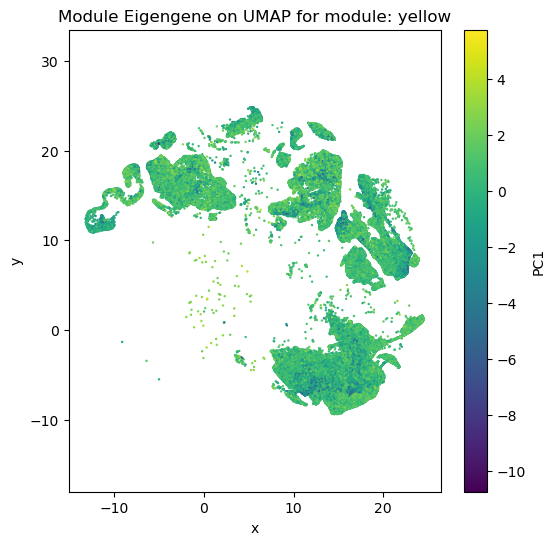

In [30]:
select_module = "yellow"
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = iso_ad.var_names.intersection(select_genes)
adata_subset = iso_ad[:,common_genes].copy()
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
plot_ME(adata_subset)